In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('final.csv')

colunas_ajustar = [
    'score_c', 'score_d', 'peso_v', 'peso_h', 'extensao_metros',
     'score_risco', 'peso_infra', 'velocidade_maxima'
]

# 2. Loop para tratar e converter todas de uma vez
for col in colunas_ajustar:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(',', '.'),
            errors='coerce'
        )

features = [

    'score_c',
    'score_d',
    'peso_v',
    'peso_h',
    'peso_infra',
    'velocidade_maxima',
    'extensao_metros'

]


X = df[features].copy()

X = X.fillna(0)



scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

np.log1p(df['score_c'])

kmeans = KMeans(

    n_clusters=5,
    random_state=42

)

df['cluster_kmeans'] = (
    kmeans.fit_predict(X_scaled)
)

df.groupby('cluster_kmeans')[features].mean()
mapa_clusters = {

    0: 'Risco estrutural',
    1: 'Baixo risco',
    2: 'Infraestrutura inadequada',
    3: 'Alto risco criminal',
    4: 'Alto risco viário'

}

df['categoria_cluster'] = (
    df['cluster_kmeans']
    .map(mapa_clusters)
)



# **Gráficos**
#Boxplot de cada variável

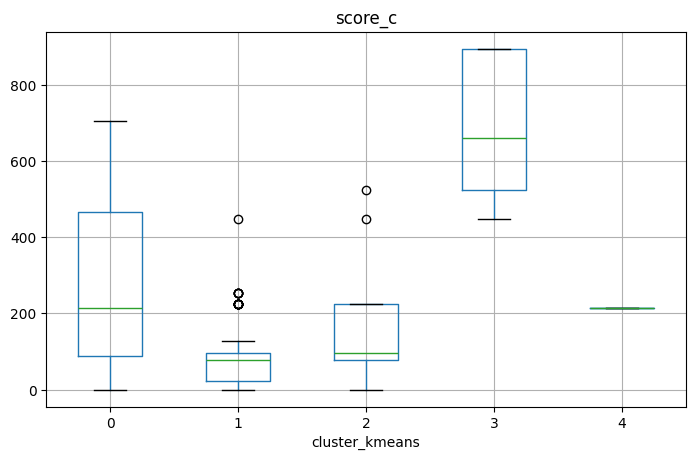

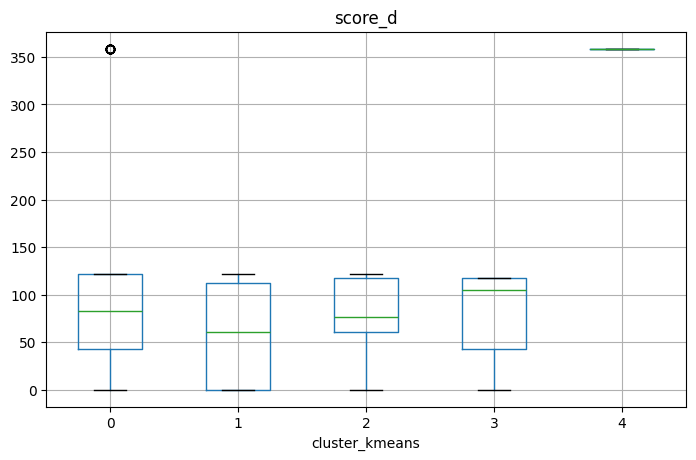

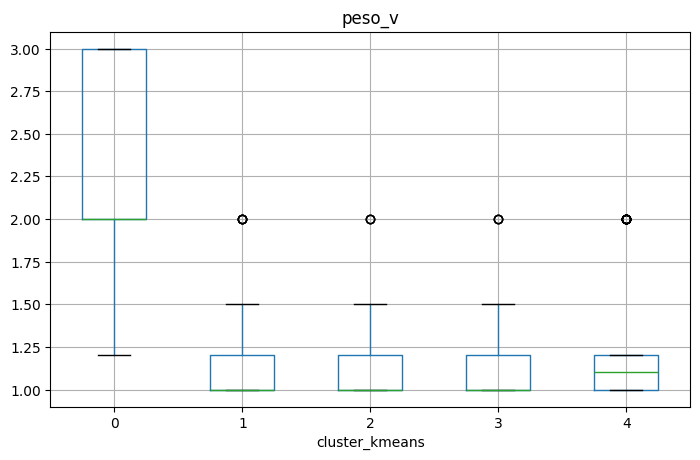

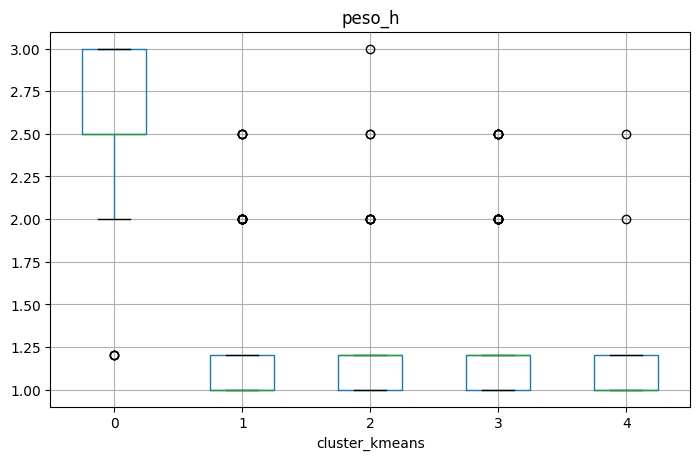

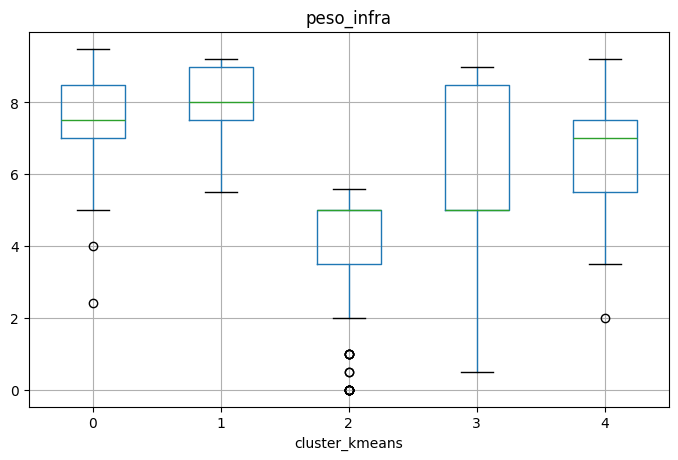

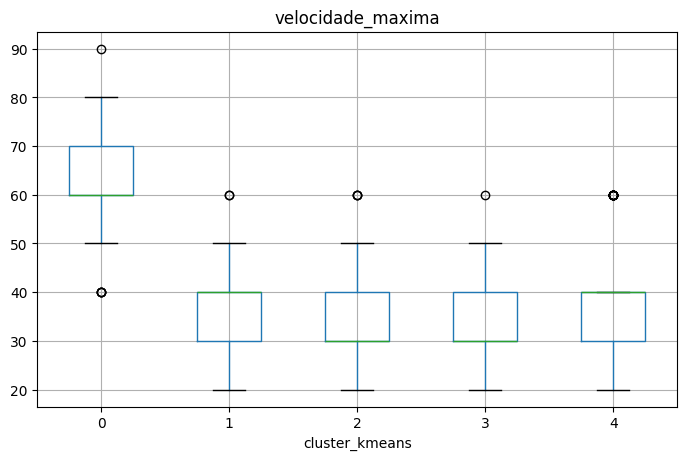

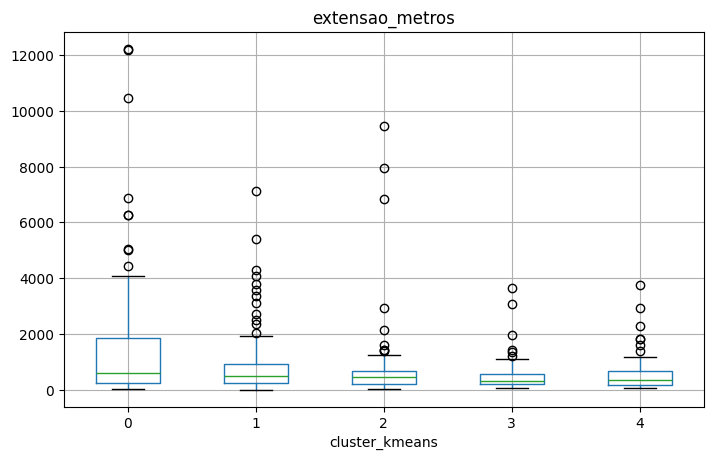

In [33]:
for col in features:

    df.boxplot(

        column=col,
        by='cluster_kmeans',
        figsize=(8,5)
    )

    plt.title(col)
    plt.suptitle('')

    plt.show()

# Heatmap das médias dos clusters

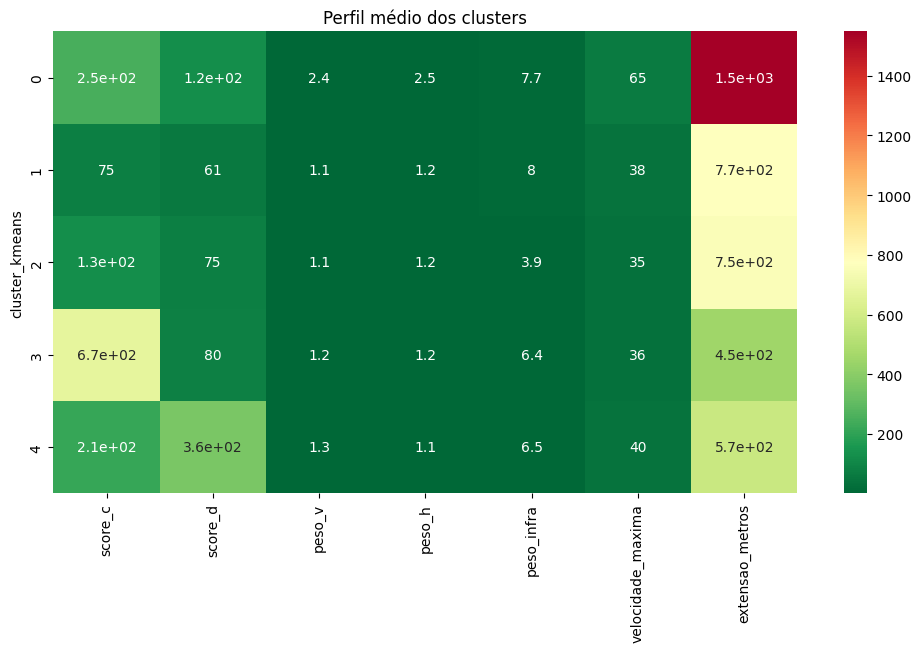

In [24]:
import seaborn as sns

medias = df.groupby(

    'cluster_kmeans'

)[features].mean()

plt.figure(figsize=(12,6))

sns.heatmap(

    medias,
    annot=True,
    cmap='RdYlGn_r'
)

plt.title('Perfil médio dos clusters')

plt.show()

# Distribuição de vias por cluster

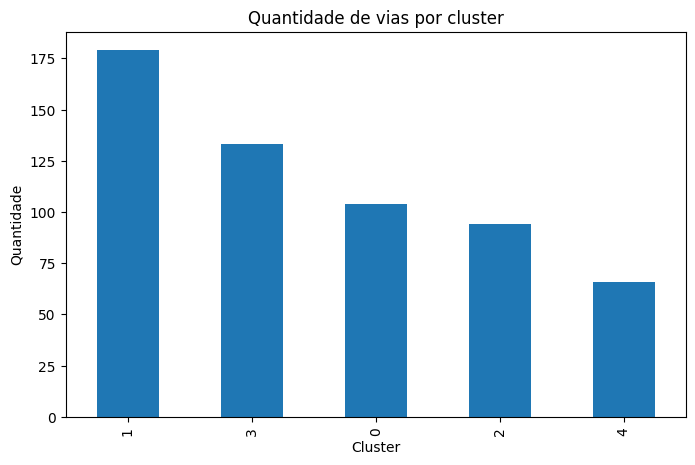

In [26]:
df['cluster_kmeans'].value_counts().plot(

    kind='bar',
    figsize=(8,5)
)

plt.title('Quantidade de vias por cluster')

plt.xlabel('Cluster')
plt.ylabel('Quantidade')

plt.show()

# Pairplot

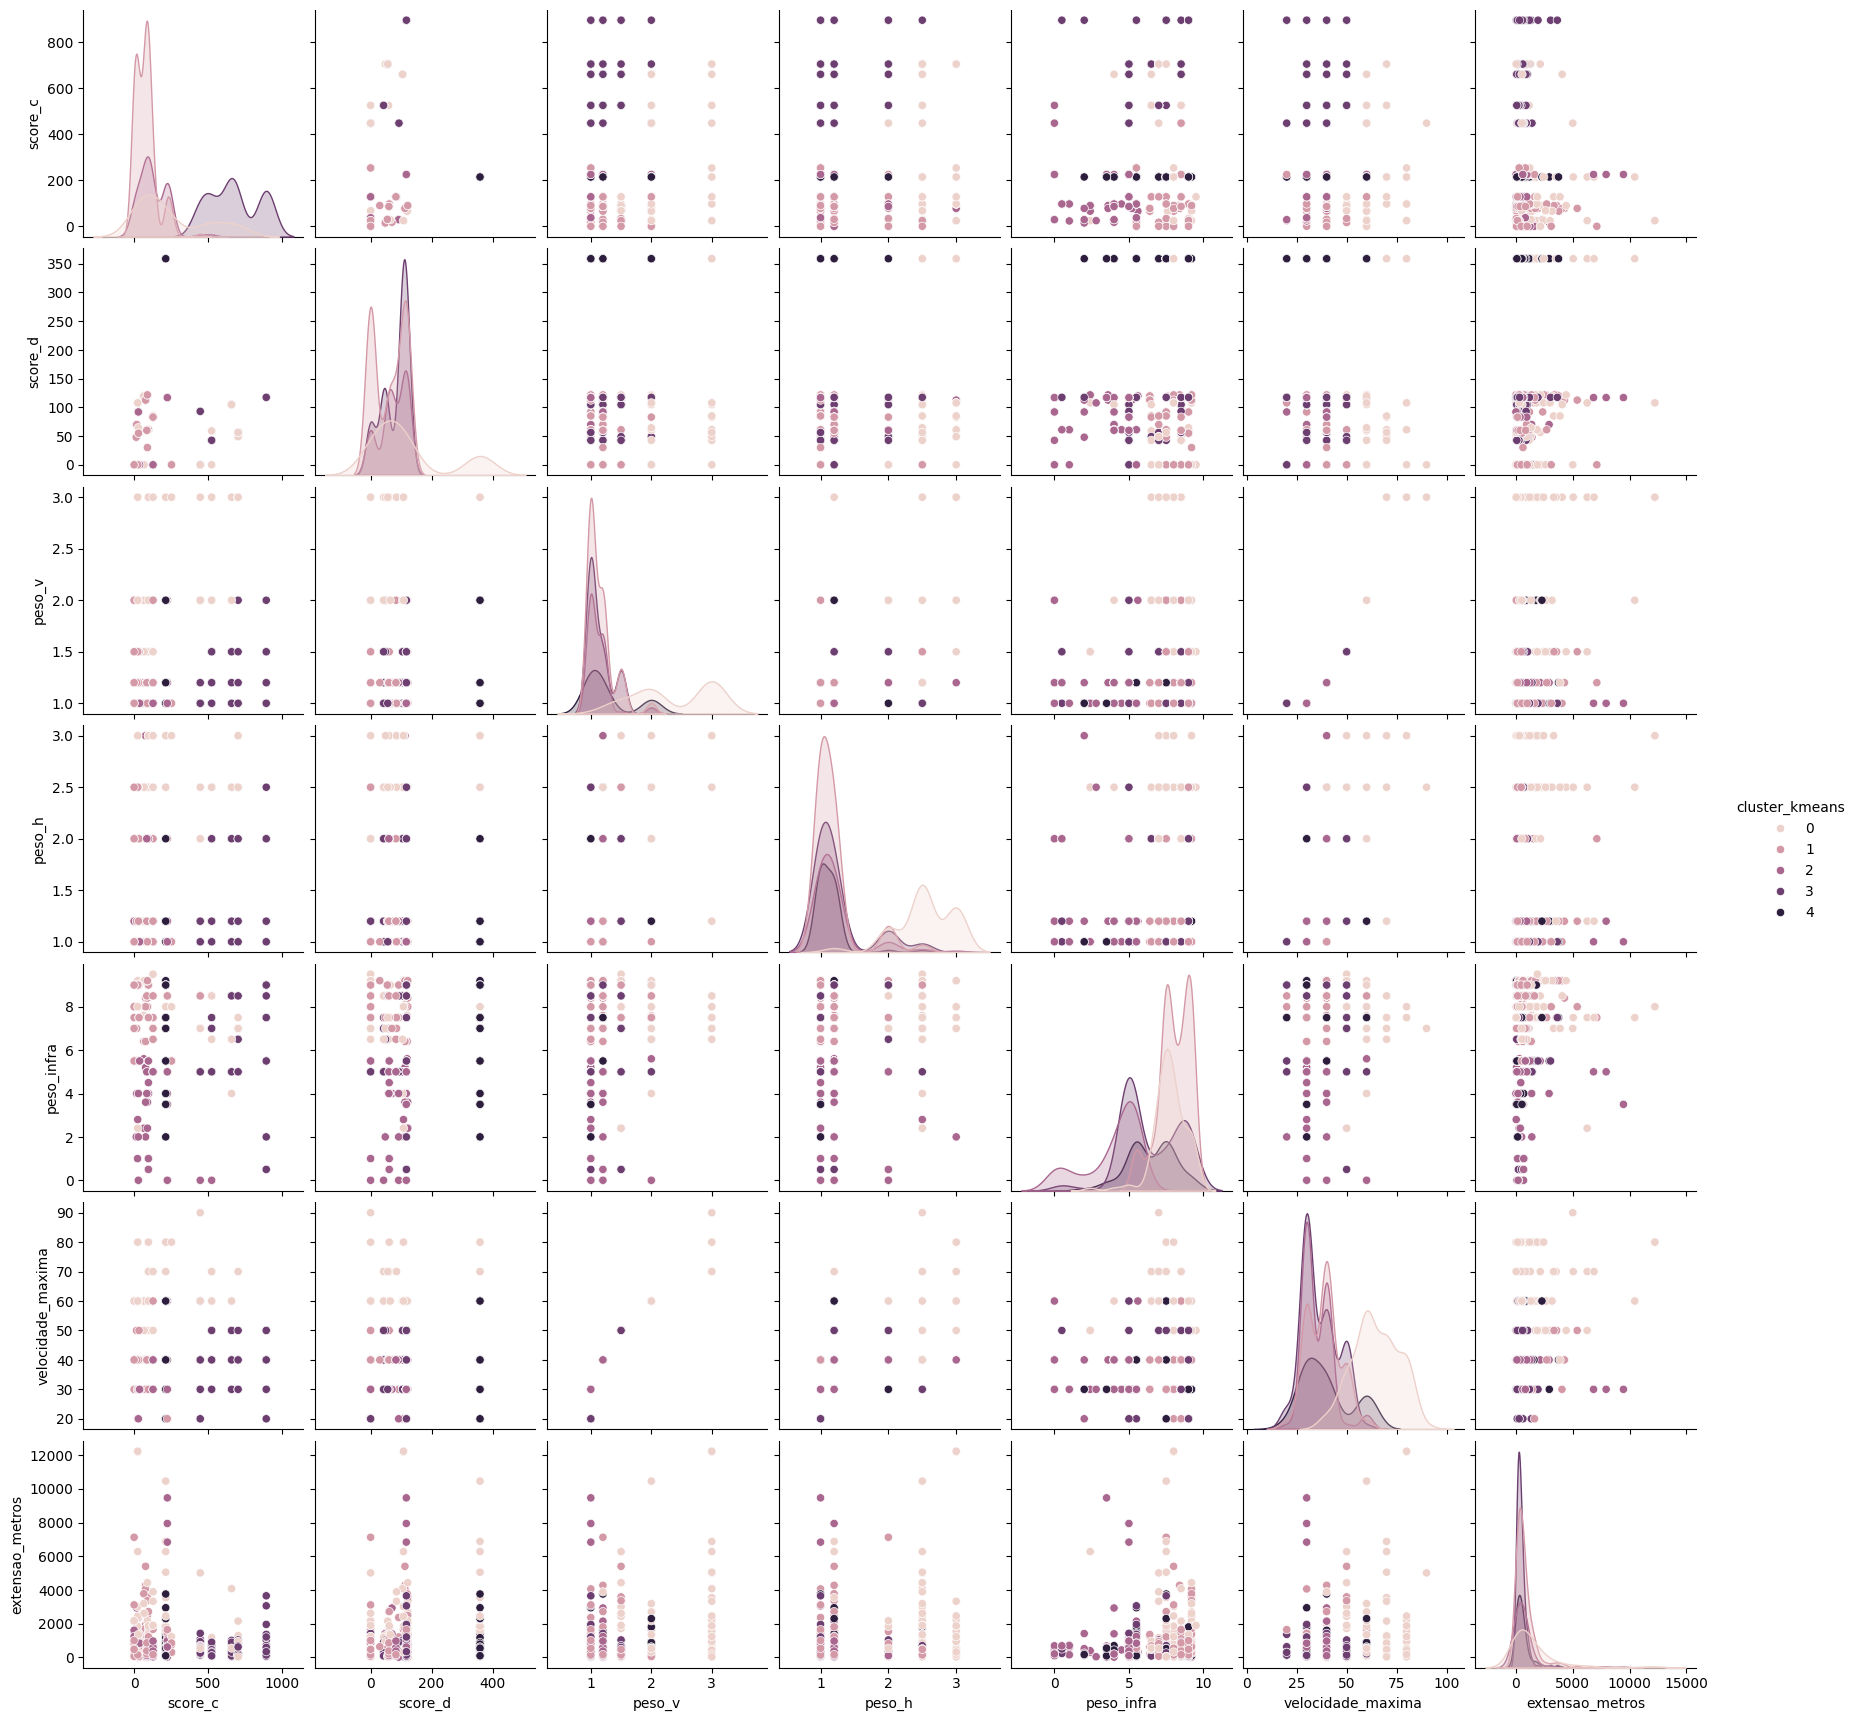

In [28]:
sns.pairplot(

    df,

    vars=features,

    hue='cluster_kmeans'
)